Grad-CAM: Visualize Model Decision Making

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization

# Define emotion labels
emotion_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# Build the exact model architecture
model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), padding='same', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(256, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Dense Layers
model.add(Flatten())

model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))

# Output
model.add(Dense(7))
model.add(Activation('softmax'))

# Load the trained weights
model.load_weights("emotion_detector.h5")
print("Model loaded successfully!")

c:\Users\thapa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model loaded successfully!


In [2]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def visualize_gradcam(image_path):
    """
    Complete Grad-CAM visualization with heatmap generation and display
    
    Args:
        image_path: Path to the test image
    """
    # Helper function: Compute gradient-based saliency map
    def get_gradcam_heatmap(img_array, emotion_idx):
        """
        Compute gradient-based saliency map for a given image and emotion class
        
        Args:
            img_array: Preprocessed image array (1, 48, 48, 1)
            emotion_idx: Index of the emotion class
        
        Returns:
            Heatmap showing which regions influenced the prediction
        """
        img_tensor = tf.Variable(img_array, dtype=tf.float32)
        
        with tf.GradientTape() as tape:
            predictions = model(img_tensor)
            target_pred = predictions[0, emotion_idx]
        
        # Compute gradients
        grads = tape.gradient(target_pred, img_tensor)
        
        # Take absolute value and average across channels
        saliency = tf.reduce_mean(tf.abs(grads), axis=-1).numpy()[0]
        
        # Normalize to 0-1 range
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
        
        return saliency
    
    # Load and preprocess image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_resized = cv2.resize(gray, (48, 48))
    face_normalized = face_resized / 255.0
    face_reshaped = np.reshape(face_normalized, (1, 48, 48, 1))
    
    # Make prediction
    predictions = model.predict(face_reshaped, verbose=0)
    emotion_idx = np.argmax(predictions)
    emotion = emotion_labels[emotion_idx]
    confidence = predictions[0][emotion_idx] * 100
    
    # Generate Grad-CAM heatmap
    heatmap = get_gradcam_heatmap(face_reshaped, emotion_idx)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0, 0].imshow(face_resized, cmap='gray')
    axes[0, 0].set_title('Original Image (48x48)')
    axes[0, 0].axis('off')
    
    # Heatmap
    im = axes[0, 1].imshow(heatmap, cmap='jet')
    axes[0, 1].set_title(f'Grad-CAM Heatmap\n(What model focused on)')
    axes[0, 1].axis('off')
    plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # Heatmap overlay on original
    heatmap_resized = cv2.resize(heatmap, (48, 48))
    overlay = (face_resized * 0.6 + heatmap_resized * 0.4 * 255).astype(np.uint8)
    axes[1, 0].imshow(overlay, cmap='gray')
    axes[1, 0].set_title('Overlay: Image + Heatmap')
    axes[1, 0].axis('off')
    
    # Predictions chart
    colors = ['red' if i == emotion_idx else 'blue' for i in range(len(emotion_labels))]
    axes[1, 1].bar(emotion_labels, predictions[0], color=colors)
    axes[1, 1].set_ylabel('Probability')
    axes[1, 1].set_title(f'Emotion: {emotion}\nConfidence: {confidence:.2f}%')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print details
    print(f"\nImage: {image_path}")
    print(f"Detected Emotion: {emotion}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"\nGrad-CAM shows which parts of the face influenced this prediction.")
    print(f"Brighter regions = more important for the '{emotion}' classification.")

## How to Use Grad-CAM:

```python
# Visualize what the model focuses on for a single image
visualize_gradcam(r"C:\path\to\your\image.jpeg")
```

**What you'll see:**
- **Top-left:** Original 48x48 image
- **Top-right:** Grad-CAM heatmap (brighter = more important)
- **Bottom-left:** Image + heatmap overlay
- **Bottom-right:** Emotion predictions chart

**Interpretation:**
- Bright regions in the heatmap = facial features the model used to make its decision
- For example, if predicting "Happy", it might focus on the mouth area
- If predicting "Angry", it might focus on the eyebrows area

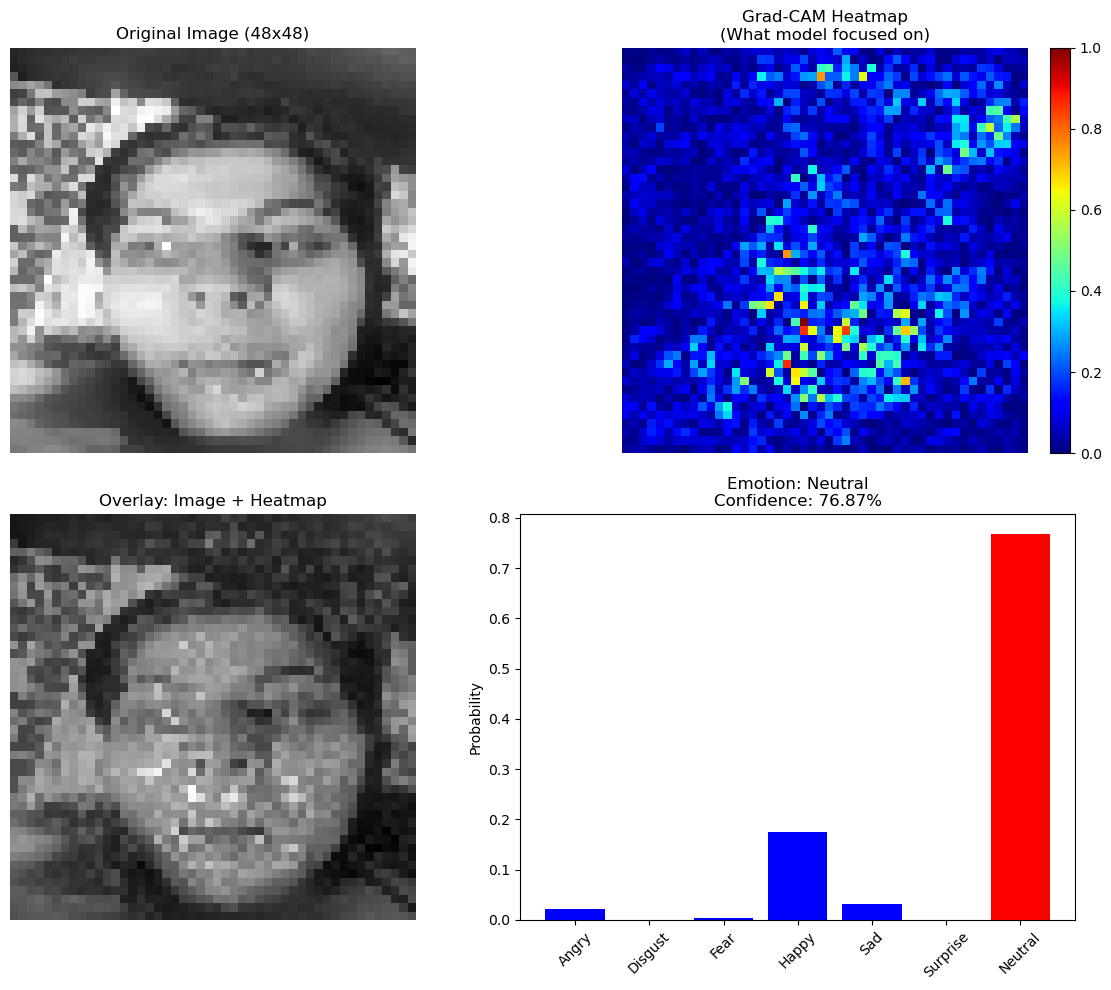


Image: ./TestImage/WhatsApp Image 2026-04-09 at 2.39.20 PM (1).jpeg
Detected Emotion: Neutral
Confidence: 76.87%

Grad-CAM shows which parts of the face influenced this prediction.
Brighter regions = more important for the 'Neutral' classification.


In [11]:
visualize_gradcam("./TestImage/WhatsApp Image 2026-04-09 at 2.39.20 PM (1).jpeg")